In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image


sns.set(style="whitegrid")


In [ ]:
# Load dataset
DATA_DIR = "/Users/aarushisharma/Downloads/archive/lfw-deepfunneled/lfw-deepfunneled"
print("Number of people folders:", len(os.listdir(DATA_DIR)))

# Collect all image paths
all_images = glob(os.path.join(DATA_DIR, "*", "*.jpg"))
print("Total images found:", len(all_images))


Number of people folders: 5749
Total images found: 13233


Unique identities: 5749
Min/Max/Mean images per person: 1 530 2.301791615933206


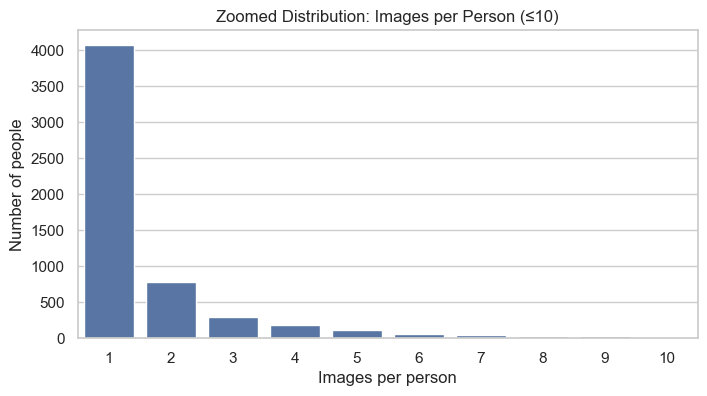

/var/folders/9n/frf4jqcj75vbkxylkp09qvzr0000gn/T/ipykernel_5432/2112629802.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="count", y="person", palette="viridis")


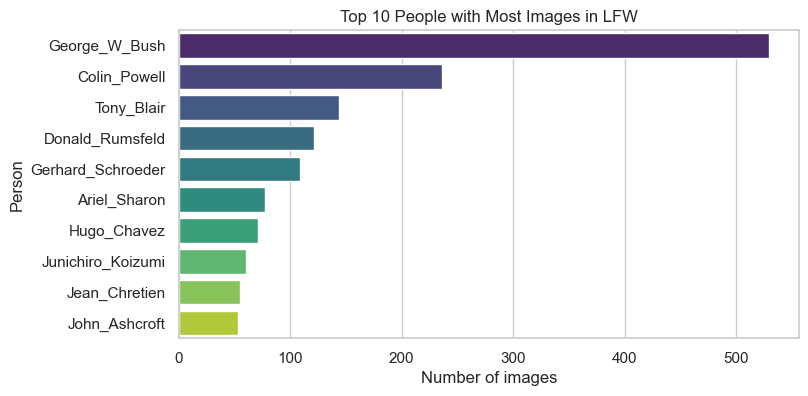

In [12]:
# Count images per person
counts = df["person"].value_counts().reset_index()
counts.columns = ["person", "count"]

print("Unique identities:", len(counts))
print("Min/Max/Mean images per person:",
      counts["count"].min(), 
      counts["count"].max(),
      counts["count"].mean())

# Plot distribution
# Plot zoomed distribution (most people have very few images)
plt.figure(figsize=(8,4))
sns.countplot(x="count", data=counts[counts["count"] <= 10])
plt.title("Zoomed Distribution: Images per Person (≤10)")
plt.xlabel("Images per person")
plt.ylabel("Number of people")
plt.show()

# Show top 10 people with most images
top10 = counts.sort_values("count", ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(data=top10, x="count", y="person", palette="viridis")
plt.title("Top 10 People with Most Images in LFW")
plt.xlabel("Number of images")
plt.ylabel("Person")
plt.show()



In [ ]:
# Image quality checks: blur & brightness
def measure_blur(img):
    """Variance of Laplacian (higher = sharper)."""
    return cv2.Laplacian(img, cv2.CV_64F).var()

def measure_brightness(img):
    """Mean pixel intensity (0=dark, 255=bright)."""
    return np.mean(img)

blur_scores, brightness_scores = [], []

for path in all_images[:2000]:  # sample first 2000 for speed
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    blur_scores.append(measure_blur(img))
    brightness_scores.append(measure_brightness(img))

df_quality = pd.DataFrame({"blur": blur_scores, "brightness": brightness_scores})


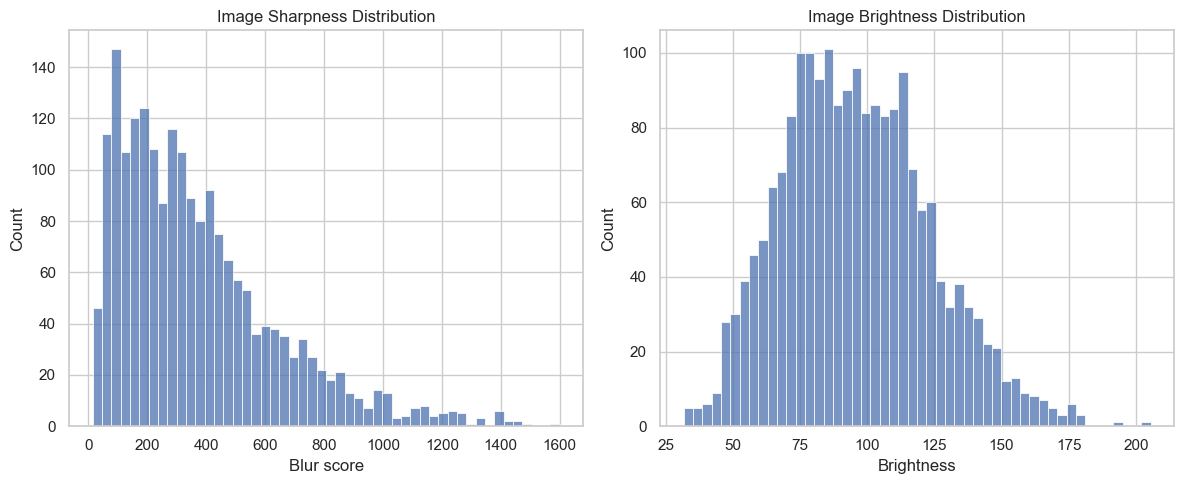

In [ ]:
# Visual exploration of quality
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_quality["blur"], bins=50)
plt.xlabel("Blur score")
plt.title("Image Sharpness Distribution")

plt.subplot(1,2,2)
sns.histplot(df_quality["brightness"], bins=50)
plt.xlabel("Brightness")
plt.title("Image Brightness Distribution")

plt.tight_layout()
plt.show()


Blurry examples:


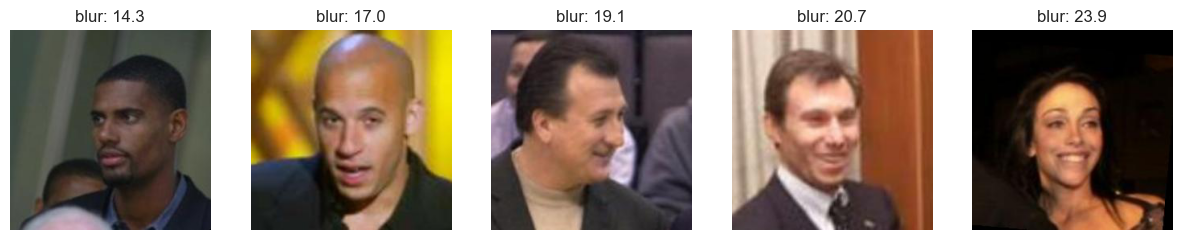

Sharp examples:


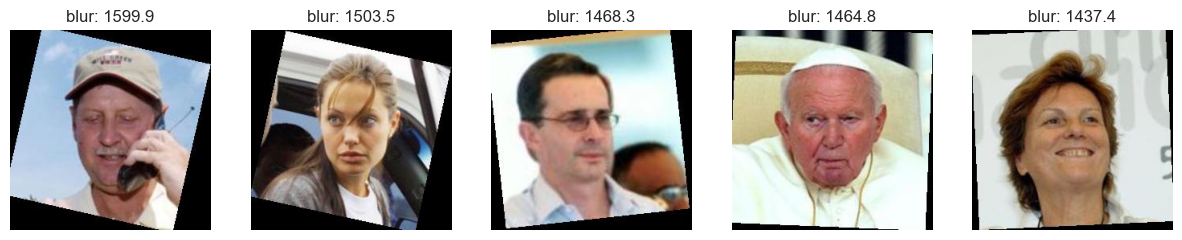

In [ ]:
# Show some examples: sharp vs blurry, bright vs dark
def show_examples(metric, n=5, best=True):
    """Show best or worst images based on given metric."""
    idx = df_quality[metric].nsmallest(n).index if not best else df_quality[metric].nlargest(n).index
    sample_paths = [all_images[i] for i in idx]
    
    plt.figure(figsize=(15,3))
    for i, path in enumerate(sample_paths):
        img = Image.open(path)
        plt.subplot(1,n,i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{metric}: {df_quality.loc[idx[i], metric]:.1f}")
    plt.show()

# Sharpest vs blurriest
print("Blurry examples:")
show_examples("blur", n=5, best=False)

print("Sharp examples:")
show_examples("blur", n=5, best=True)
